# Estrategia Comercial: Posicionamiento de Precio en Línea Blanca
**Objetivo:** Decidir el posicionamiento de precio de la marca KRONOS respecto a la competencia para los próximos 3 meses. Se evaluará el impacto conjunto de la distribución ponderada, promociones y quiebres de inventario sobre el Market Share.

**Metadata**:

* David Tinoco Romero

* A01801491

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
# 1. Importar las librerías necesarias
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Carga de Datos
ruta_archivo = r"data\datos_posicionamiento_kronos.csv"
try:
    df = pd.read_csv(ruta_archivo)
except FileNotFoundError:
    # Simulación del DataFrame con el ejemplo proporcionado si el archivo local no está disponible
    data = {
        'Fecha': ['2022-01-01'], 'Mes': [1], 'Región': ['Norte'], 
        'Precio_KRONOS': [12180.62], 'Precio_Competencia': [12248.36], 
        'Market_Share': [0.3146], 'Dist_Ponderada': [0.8024], 
        'Promoción': [0], 'Quiebre': [0.0012]
    }
    df = pd.DataFrame(data)

df.head()

,Fecha,Mes,Región,Precio_KRONOS,Precio_Competencia,Índice_Precio,Market_Share,Dist_Ponderada,Dist_Numérica,Share_en_Distribución,Promoción,Quiebre,Tamaño_Mercado,Unidades_KRONOS,Costo_Unitario,Ventas_KRONOS,Contribución
0,2022-01-01,1,Norte,12180.62,12248.36,0.9945,0.3146,0.8024,0.7730,0.3921,0,0.0012,54569,17167,8083.71,2.091046e+08,70331555.56
1,2022-02-01,2,Norte,11463.58,11709.56,0.9790,0.2925,0.7414,0.6899,0.3945,0,0.0069,47227,13814,7696.15,1.583579e+08,52043277.40
2,2022-03-01,3,Norte,10893.73,11545.99,0.9435,0.3239,0.8433,0.8113,0.3841,0,0.0180,49322,15974,8036.67,1.740164e+08,45638749.14
3,2022-04-01,4,Norte,12143.27,11699.87,1.0379,0.2954,0.7846,0.7381,0.3765,1,0.0137,48093,14206,8246.76,1.725073e+08,55353773.15
4,2022-05-01,5,Norte,11155.60,12104.43,0.9216,0.3361,0.7036,0.6254,0.4777,1,0.0298,50590,17002,8221.54,1.896676e+08,49884957.64


# 0. EDA
En esta sección exploraremos visualmente la base de datos para entender la distribución de nuestras variables (análisis univariado) y cómo se relacionan las palancas comerciales con nuestra variable objetivo: el **Market Share** (análisis bivariado).

In [2]:
# Importar librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de las gráficas
sns.set_theme(style="whitegrid")

## a) Análisis Univariado: Variable Objetivo
Primero, observamos cómo se distribuye nuestra participación de mercado históricamente para identificar su sesgo, media y dispersión.

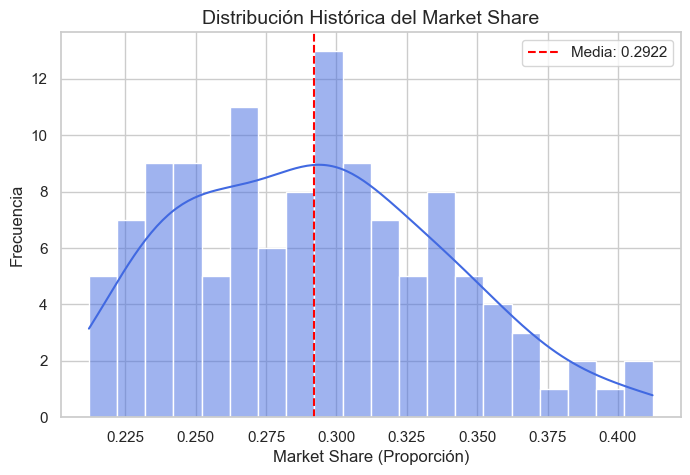

In [3]:
# Distribución del Market Share
plt.figure(figsize=(8, 5))
sns.histplot(df['Market_Share'], kde=True, bins=20, color='royalblue')
plt.title('Distribución Histórica del Market Share', fontsize=14)
plt.xlabel('Market Share (Proporción)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.axvline(df['Market_Share'].mean(), color='red', linestyle='--', label=f"Media: {df['Market_Share'].mean():.4f}")
plt.legend()
plt.show()

## b) Análisis Univariado: Palancas Comerciales (Features)
Evaluamos la distribución de las variables continuas (precio, distribución, quiebre) y el conteo de nuestras variables categóricas/binarias (promoción, estacionalidad, región).

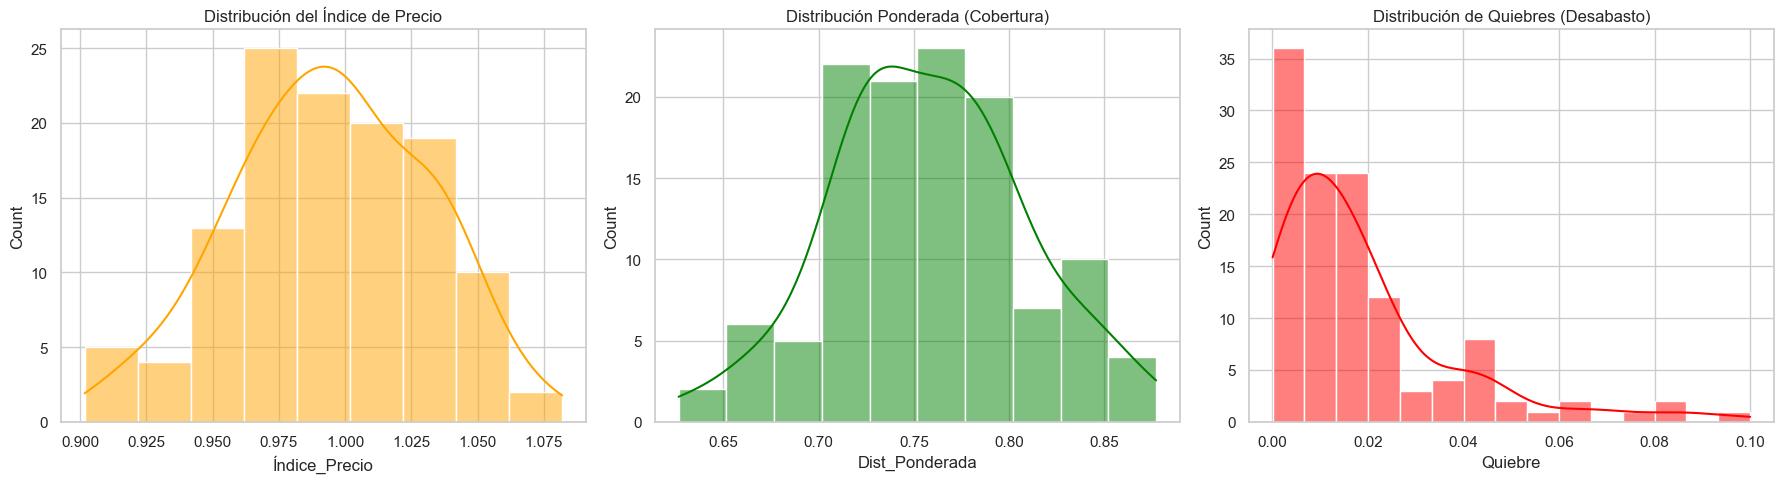

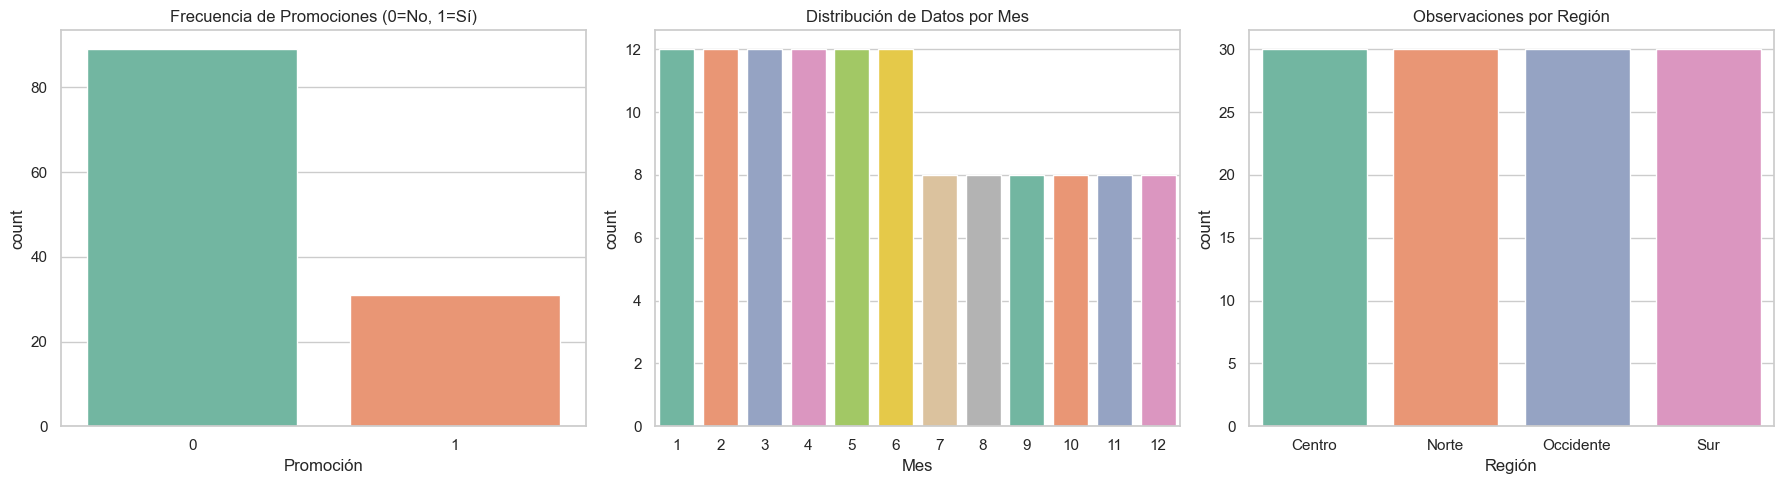

In [4]:
# Configurar figura para variables continuas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Índice_Precio'], kde=True, ax=axes[0], color='orange')
axes[0].set_title('Distribución del Índice de Precio')

sns.histplot(df['Dist_Ponderada'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribución Ponderada (Cobertura)')

sns.histplot(df['Quiebre'], kde=True, ax=axes[2], color='red')
axes[2].set_title('Distribución de Quiebres (Desabasto)')

plt.tight_layout()
plt.show()

# Configurar figura para variables categóricas/binarias
# Usamos las columnas originales: Promoción, Mes y Región
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='Promoción', ax=axes[0], palette='Set2')
axes[0].set_title('Frecuencia de Promociones (0=No, 1=Sí)')

# Graficamos los meses directamente para ver la estacionalidad previa a la creación de la dummy
sns.countplot(data=df, x='Mes', ax=axes[1], palette='Set2')
axes[1].set_title('Distribución de Datos por Mes')

sns.countplot(data=df, x='Región', ax=axes[2], palette='Set2', order=['Centro', 'Norte', 'Occidente', 'Sur'])
axes[2].set_title('Observaciones por Región')

plt.tight_layout()
plt.show()

## c) Análisis Bivariado: Relación de las Features vs. Variable Objetivo
Ahora cruzamos cada palanca comercial contra el Market Share para identificar visualmente las tendencias (pendientes positivas o negativas) antes de correr el modelo matemático.

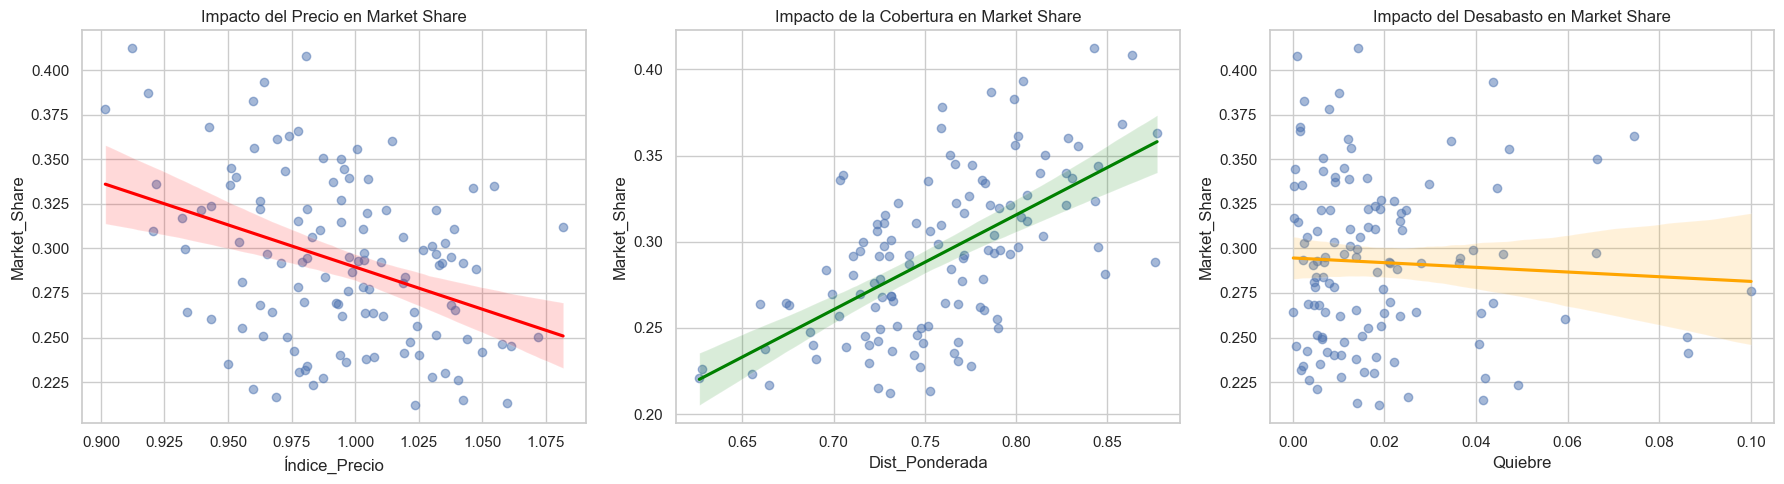

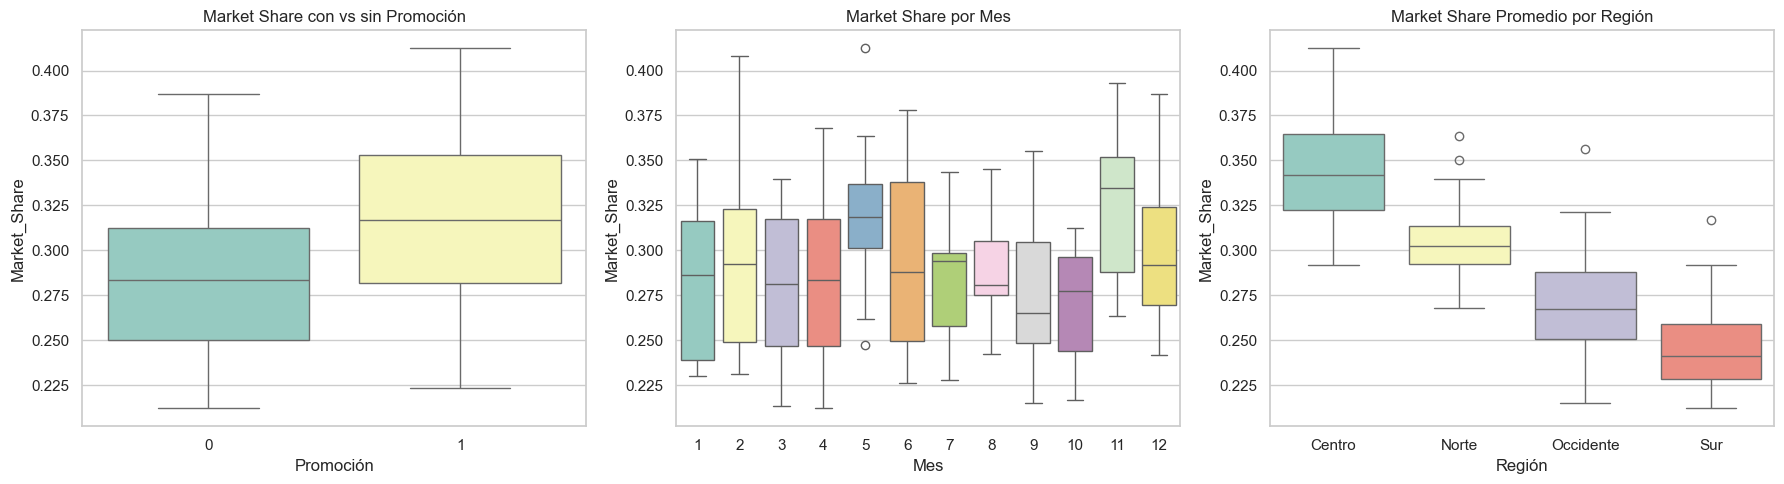

In [5]:
# Relación de variables continuas vs Market Share (Scatter plots con línea de tendencia)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(data=df, x='Índice_Precio', y='Market_Share', ax=axes[0], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[0].set_title('Impacto del Precio en Market Share')

sns.regplot(data=df, x='Dist_Ponderada', y='Market_Share', ax=axes[1], scatter_kws={'alpha':0.5}, line_kws={'color':'green'})
axes[1].set_title('Impacto de la Cobertura en Market Share')

sns.regplot(data=df, x='Quiebre', y='Market_Share', ax=axes[2], scatter_kws={'alpha':0.5}, line_kws={'color':'orange'})
axes[2].set_title('Impacto del Desabasto en Market Share')

plt.tight_layout()
plt.show()

# Relación de variables categóricas vs Market Share (Boxplots)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='Promoción', y='Market_Share', ax=axes[0], palette='Set3')
axes[0].set_title('Market Share con vs sin Promoción')

# Usamos la columna 'Mes' para visualizar la estacionalidad
sns.boxplot(data=df, x='Mes', y='Market_Share', ax=axes[1], palette='Set3')
axes[1].set_title('Market Share por Mes')

sns.boxplot(data=df, x='Región', y='Market_Share', ax=axes[2], palette='Set3', order=['Centro', 'Norte', 'Occidente', 'Sur'])
axes[2].set_title('Market Share Promedio por Región')

plt.tight_layout()
plt.show()

## d) Matriz de Correlación General
Visualizamos el mapa de calor (Heatmap) para comprobar de un vistazo las correlaciones lineales entre todas nuestras variables accionables y el Market Share, además de descartar multicolinealidad severa entre las variables independientes.

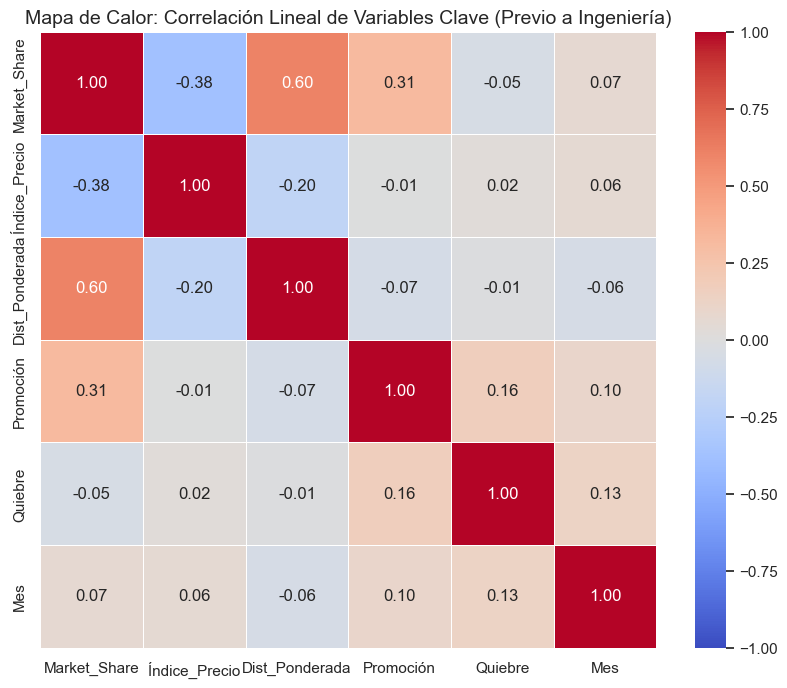

In [6]:
plt.figure(figsize=(10, 8))
# Seleccionamos las variables clave disponibles en este momento
vars_corr = ['Market_Share', 'Índice_Precio', 'Dist_Ponderada', 'Promoción', 'Quiebre', 'Mes']

# Calculamos la matriz de correlación
matriz_corr = df[vars_corr].corr()

# Graficamos el Heatmap
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title('Mapa de Calor: Correlación Lineal de Variables Clave (Previo a Ingeniería)', fontsize=14)
plt.show()

# 1. Ingeniería de Características y Variables Dummy
Preparación de las variables independientes para el modelo:
1. **Es_Temporada_Alta:** Variable dummy (1 para Nov/Dic, 0 para otros).
2. **Índice_Precio:** Razón matemática para la palanca de pricing.
3. **Dummies de Región:** Categorización excluyendo la región "Centro" para evitar la trampa de la variable dummy (multicolinealidad perfecta).

In [7]:
# Asegurar formato de fecha y extraer mes
df['Fecha'] = pd.to_datetime(df['Fecha'])
df['Mes_Extraido'] = df['Fecha'].dt.month

In [8]:
print('meses unicos: ', df['Mes_Extraido'].nunique())
print('meses: ', df['Mes_Extraido'].unique())

meses unicos:  12
meses:  [ 1  2  3  4  5  6  7  8  9 10 11 12]


In [9]:

# Variable dummy: Es_Temporada_Alta (1 para Noviembre y Diciembre)
df['Es_Temporada_Alta'] = df['Mes_Extraido'].apply(lambda x: 1 if x in [11, 12] else 0)

# Crear la variable Índice_Precio (Precio KRONOS / Precio Competencia)
df['Índice_Precio'] = df['Precio_KRONOS'] / df['Precio_Competencia']

# Variables Dummy para 'Región', tomando 'Centro' como categoría de referencia
# dtype=int asegura que se creen como 0s y 1s numéricos
dummies_region = pd.get_dummies(df['Región'], prefix='Región', dtype=int)

# Eliminamos la región Centro para que sea nuestra base (ordenada en el origen)
if 'Región_Centro' in dummies_region.columns:
    dummies_region = dummies_region.drop('Región_Centro', axis=1)

# Concatenar al DataFrame original
df = pd.concat([df, dummies_region], axis=1)
df.head()

,Fecha,Mes,Región,Precio_KRONOS,Precio_Competencia,Índice_Precio,Market_Share,Dist_Ponderada,Dist_Numérica,Share_en_Distribución,...,Tamaño_Mercado,Unidades_KRONOS,Costo_Unitario,Ventas_KRONOS,Contribución,Mes_Extraido,Es_Temporada_Alta,Región_Norte,Región_Occidente,Región_Sur
0,2022-01-01,1,Norte,12180.62,12248.36,0.994469,0.3146,0.8024,0.7730,0.3921,...,54569,17167,8083.71,2.091046e+08,70331555.56,1,0,1,0,0
1,2022-02-01,2,Norte,11463.58,11709.56,0.978993,0.2925,0.7414,0.6899,0.3945,...,47227,13814,7696.15,1.583579e+08,52043277.40,2,0,1,0,0
2,2022-03-01,3,Norte,10893.73,11545.99,0.943508,0.3239,0.8433,0.8113,0.3841,...,49322,15974,8036.67,1.740164e+08,45638749.14,3,0,1,0,0
3,2022-04-01,4,Norte,12143.27,11699.87,1.037898,0.2954,0.7846,0.7381,0.3765,...,48093,14206,8246.76,1.725073e+08,55353773.15,4,0,1,0,0
4,2022-05-01,5,Norte,11155.60,12104.43,0.921613,0.3361,0.7036,0.6254,0.4777,...,50590,17002,8221.54,1.896676e+08,49884957.64,5,0,1,0,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Fecha                  120 non-null    datetime64[ns]
 1   Mes                    120 non-null    int64         
 2   Región                 120 non-null    object        
 3   Precio_KRONOS          120 non-null    float64       
 4   Precio_Competencia     120 non-null    float64       
 5   Índice_Precio          120 non-null    float64       
 6   Market_Share           120 non-null    float64       
 7   Dist_Ponderada         120 non-null    float64       
 8   Dist_Numérica          120 non-null    float64       
 9   Share_en_Distribución  120 non-null    float64       
 10  Promoción              120 non-null    int64         
 11  Quiebre                120 non-null    float64       
 12  Tamaño_Mercado         120 non-null    int64         
 13  Unida

In [11]:
df.describe()

,Fecha,Mes,Precio_KRONOS,Precio_Competencia,Índice_Precio,Market_Share,Dist_Ponderada,Dist_Numérica,Share_en_Distribución,Promoción,...,Tamaño_Mercado,Unidades_KRONOS,Costo_Unitario,Ventas_KRONOS,Contribución,Mes_Extraido,Es_Temporada_Alta,Región_Norte,Región_Occidente,Región_Sur
count,120,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,...,120.000000,120.000000,120.000000,1.200000e+02,1.200000e+02,120.000000,120.000000,120.000000,120.000000,120.000000
mean,2023-03-17 08:48:00,5.900000,11941.642500,12008.157583,0.994498,0.292168,0.757331,0.710262,0.385057,0.258333,...,50314.900000,14703.325000,7963.381250,1.753133e+08,5.817860e+07,5.900000,0.133333,0.250000,0.250000,0.250000
min,2022-01-01 00:00:00,1.000000,10477.800000,10980.940000,0.901730,0.212100,0.626500,0.561600,0.283400,0.000000,...,42021.000000,10433.000000,7249.170000,1.140544e+08,2.824697e+07,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2022-08-01 00:00:00,3.000000,11509.190000,11699.657500,0.969031,0.254400,0.724250,0.676050,0.343700,0.000000,...,48376.750000,12564.750000,7768.302500,1.517636e+08,4.883192e+07,3.000000,0.000000,0.000000,0.000000,0.000000
50%,2023-03-16 12:00:00,5.500000,11924.980000,12013.240000,0.994739,0.292100,0.758050,0.708400,0.385800,0.000000,...,50606.000000,14470.000000,7940.775000,1.737256e+08,5.679620e+07,5.500000,0.000000,0.000000,0.000000,0.000000
75%,2023-11-01 00:00:00,9.000000,12340.750000,12247.085000,1.023333,0.322300,0.789500,0.738350,0.417075,1.000000,...,52257.250000,16769.750000,8169.077500,2.018240e+08,6.784571e+07,9.000000,0.000000,0.250000,0.250000,0.250000
max,2024-06-01 00:00:00,12.000000,13508.210000,13284.960000,1.081896,0.412300,0.877200,0.842500,0.497800,1.000000,...,57365.000000,20180.000000,8712.240000,2.268028e+08,8.854228e+07,12.000000,1.000000,1.000000,1.000000,1.000000
std,NaN,3.413764,627.739614,457.822824,0.036901,0.046391,0.051013,0.053665,0.049505,0.439554,...,2874.000115,2486.859753,287.787794,2.920395e+07,1.246006e+07,3.413764,0.341360,0.434828,0.434828,0.434828


## a) Justificación de Selección de Variables

### 1. Alineación con las Instrucciones del Negocio

In [12]:
columnas_region = dummies_region.columns.tolist()

# Variables totales en el dataset original
todas_las_columnas = df.columns.tolist()

# Palancas accionables definidas por el negocio
palancas_negocio = ['Índice_Precio', 'Dist_Ponderada', 'Promoción', 'Quiebre', 'Es_Temporada_Alta']

# Variables descartadas por no ser palancas de interés primario para este modelo
variables_descartadas = [col for col in todas_las_columnas if col not in palancas_negocio and col not in columnas_region and col != 'Market_Share']

print("Palancas evaluadas en el modelo OLS:")
print(palancas_negocio)
print("\nVariables excluidas del set de características (X):")
print(variables_descartadas)

Palancas evaluadas en el modelo OLS:
['Índice_Precio', 'Dist_Ponderada', 'Promoción', 'Quiebre', 'Es_Temporada_Alta']

Variables excluidas del set de características (X):
['Fecha', 'Mes', 'Región', 'Precio_KRONOS', 'Precio_Competencia', 'Dist_Numérica', 'Share_en_Distribución', 'Tamaño_Mercado', 'Unidades_KRONOS', 'Costo_Unitario', 'Ventas_KRONOS', 'Contribución', 'Mes_Extraido']


La selección de características (features) no es un proceso puramente estadístico; responde a las reglas y objetivos del negocio. Se definió exactamente cuáles son las "palancas" comerciales que pueden accionar y que desean evaluar (Precio, Distribución, Promociones, Quiebres y Estacionalidad). Incluir otras variables desenfocaría el análisis del objetivo principal.

### 2. Prevención de Fuga de Datos (Endogeneidad)

Matriz de Correlación: Fuga de Datos
Market_Share       1.000000
Ventas_KRONOS      0.871211
Unidades_KRONOS    0.943507
Contribución       0.524696
Name: Market_Share, dtype: float64


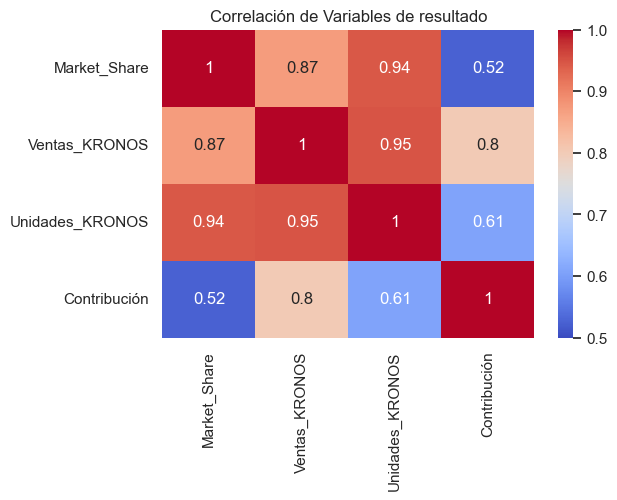

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Variables de resultado (consecuencias de la venta, no predictores válidos)
vars_resultado = ['Market_Share', 'Ventas_KRONOS', 'Unidades_KRONOS', 'Contribución']

# Correlación entre la variable dependiente y las variables de resultado
correlacion_resultados = df[vars_resultado].corr()

print("Matriz de Correlación: Fuga de Datos")
print(correlacion_resultados['Market_Share'])

# Visualización rápida de la fuga de datos
plt.figure(figsize=(6, 4))
sns.heatmap(correlacion_resultados, annot=True, cmap='coolwarm', vmin=0.5, vmax=1)
plt.title("Correlación de Variables de resultado")
plt.show()

Si incluimos variables como `Ventas_KRONOS`, `Unidades_KRONOS` o `Contribución` para predecir el `Market_Share`, el modelo cometerá "fuga de datos". Estas variables son el resultado matemático directo de tener participación de mercado, no la causa. Si las metemos a la regresión, el modelo tendrá un $R^2$ engañosamente perfecto, pero será inútil para predecir el futuro a partir de palancas comerciales.

### 3. Redundancia de Información (Multicolinealidad)


In [14]:
# Análisis de correlación de variables redundantes
vars_redundantes_dist = ['Dist_Ponderada', 'Dist_Numérica']
vars_redundantes_precio = ['Índice_Precio', 'Precio_KRONOS', 'Precio_Competencia']

corr_dist = df[vars_redundantes_dist].corr()
corr_precio = df[vars_redundantes_precio].corr()

print("Correlación entre variables de Distribución:")
print(corr_dist)
print("\nCorrelación entre el Índice y los precios individuales:")
print(corr_precio)

Correlación entre variables de Distribución:
                Dist_Ponderada  Dist_Numérica
Dist_Ponderada        1.000000       0.943358
Dist_Numérica         0.943358       1.000000

Correlación entre el Índice y los precios individuales:
                    Índice_Precio  Precio_KRONOS  Precio_Competencia
Índice_Precio            1.000000       0.687668           -0.026886
Precio_KRONOS            0.687668       1.000000            0.706726
Precio_Competencia      -0.026886       0.706726            1.000000


La regresión lineal requiere que las variables independientes no estén altamente correlacionadas entre sí. 
* Si incluimos `Precio_KRONOS`, `Precio_Competencia` e `Índice_Precio` simultáneamente, estamos repitiendo el mismo dato matemático. 
* Lo mismo ocurre con `Dist_Numérica` y `Dist_Ponderada`. 
Incluirlas juntas "confunde" al modelo matemático y dispara el Factor de Inflación de Varianza (VIF), volviendo los coeficientes inestables.

### 4. Variables de Formato (Fechas) e Identificadores Categóricos


In [15]:
# Mostrar el tipo de dato original de la variable Fecha
print("Tipo de dato de 'Fecha':", df['Fecha'].dtype)

# Mostrar por qué 'Mes' no debe ser continuo
impacto_dummy = df.groupby('Es_Temporada_Alta')['Market_Share'].mean()

print("\nPromedio de Market Share por Temporada (Dummy):")
print(f"Temporada Baja (0): {impacto_dummy[0]:.4f}")
print(f"Temporada Alta (1): {impacto_dummy[1]:.4f}")

Tipo de dato de 'Fecha': datetime64[ns]

Promedio de Market Share por Temporada (Dummy):
Temporada Baja (0): 0.2888
Temporada Alta (1): 0.3142


Variables como `Fecha` (formato datetime) o `Mes` (formato numérico secuencial del 1 al 12) no pueden entrar directamente a una regresión OLS. Si metemos `Mes` tal cual, la regresión asume un impacto lineal continuo (creyendo que el mes de diciembre, al valer 12, tiene 12 veces más impacto inherente que enero, que vale 1). Para manejar esta estacionalidad de forma estadísticamente correcta, "comprimimos" la información temporal en la variable dummy `Es_Temporada_Alta`.

## b) Variables finales del modelo

In [16]:
# Definir las variables del modelo
columnas_region = dummies_region.columns.tolist()
features = ['Índice_Precio', 'Dist_Ponderada', 'Promoción', 'Quiebre', 'Es_Temporada_Alta'] + columnas_region

# Extraer X e Y, forzando a float para evitar errores internos en statsmodels
X = df[features].astype(float)
Y = df['Market_Share'].astype(float)

# Añadir constante (ordenada en el origen)
X = sm.add_constant(X)

In [17]:
Y.head(5)

0    0.3146
1    0.2925
2    0.3239
3    0.2954
4    0.3361
Name: Market_Share, dtype: float64

In [18]:
X.head(5)

,const,Índice_Precio,Dist_Ponderada,Promoción,Quiebre,Es_Temporada_Alta,Región_Norte,Región_Occidente,Región_Sur
0,1.0,0.994469,0.8024,0.0,0.0012,0.0,1.0,0.0,0.0
1,1.0,0.978993,0.7414,0.0,0.0069,0.0,1.0,0.0,0.0
2,1.0,0.943508,0.8433,0.0,0.0180,0.0,1.0,0.0,0.0
3,1.0,1.037898,0.7846,1.0,0.0137,0.0,1.0,0.0,0.0
4,1.0,0.921613,0.7036,1.0,0.0298,0.0,1.0,0.0,0.0


# 2. Transformación y Escalamiento de Datos:

## a) Evaluación Econométrica: Modelo OLS y Multicolinealidad
Ajuste de la regresión con datos originales para evaluar la magnitud real de los coeficientes (cambios en $Y$ por cada unidad de cambio en $X$). Posteriormente, se calculará el Factor de Inflación de Varianza (VIF).

In [19]:
# Ajustar el modelo OLS
modelo_ols = sm.OLS(Y, X).fit()
print(modelo_ols.summary())

# Calcular el VIF para probar multicolinealidad
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\n--- Factor de Inflación de Varianza (VIF) ---")
print(vif_data)

                            OLS Regression Results                            
Dep. Variable:           Market_Share   R-squared:                       0.949
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     258.0
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           5.27e-68
Time:                        22:04:02   Log-Likelihood:                 377.22
No. Observations:                 120   AIC:                            -736.4
Df Residuals:                     111   BIC:                            -711.4
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.4219      0.03

### Validación de Supuestos del Modelo

- **Autocorrelación de residuos (Durbin-Watson):** El estadístico obtenido es de 2.33, muy cercano a 2. 
  Esto indica que no hay evidencia de autocorrelación significativa entre los residuos, por lo que 
  los errores estándar de los coeficientes son confiables.

- **Normalidad de los residuos (Jarque-Bera / Omnibus):** El p-value de la prueba Jarque-Bera es alto 
  (0.871), por lo que no se rechaza la hipótesis nula de normalidad. Esto valida el uso de los 
  intervalos de confianza y predicción calculados más adelante, ya que dependen del supuesto de 
  normalidad en los errores.

- **Multicolinealidad (VIF):** Todos los VIF de las variables predictoras están por debajo de 2 
  (máximo 1.73 en Región_Sur), muy lejos del umbral de preocupación (>5 o >10). El VIF de la 
  constante (1276) es un artefacto normal de statsmodels al no centrar las variables y **no indica 
  colinealidad real**; se ignora en la interpretación.

- **Homocedasticidad:** De forma visual, se puede complementar esta validación con un gráfico de 
  residuos vs. valores ajustados (ver celda siguiente) para descartar patrones de varianza no constante.

## b) Modelo Estandarizado (Coeficientes Beta)
Para entender qué variable tiene el mayor peso relativo sobre el *Market Share*, estandarizamos las variables continuas y reestimamos el modelo.

**Nota metodológica:** Solo se estandarizan las variables continuas (`Índice_Precio`, `Dist_Ponderada`, 
`Quiebre`). Las variables binarias (`Promoción`, `Es_Temporada_Alta`, dummies de `Región`) se dejan en 
su escala original (0/1), ya que estandarizar una variable dummy no tiene una interpretación 
significativa (su desviación estándar no representa una unidad de cambio real) y distorsionaría la 
lectura de los coeficientes Beta.

In [20]:
# Estandarizar solo las variables continuas
vars_continuas = ['Índice_Precio', 'Dist_Ponderada', 'Quiebre']
scaler = StandardScaler()

df_std = df.copy()
df_std[vars_continuas] = scaler.fit_transform(df[vars_continuas])

In [21]:
df_std.describe()

,Fecha,Mes,Precio_KRONOS,Precio_Competencia,Índice_Precio,Market_Share,Dist_Ponderada,Dist_Numérica,Share_en_Distribución,Promoción,...,Tamaño_Mercado,Unidades_KRONOS,Costo_Unitario,Ventas_KRONOS,Contribución,Mes_Extraido,Es_Temporada_Alta,Región_Norte,Región_Occidente,Región_Sur
count,120,120.000000,120.000000,120.000000,1.200000e+02,120.000000,1.200000e+02,120.000000,120.000000,120.000000,...,120.000000,120.000000,120.000000,1.200000e+02,1.200000e+02,120.000000,120.000000,120.000000,120.000000,120.000000
mean,2023-03-17 08:48:00,5.900000,11941.642500,12008.157583,-1.850372e-15,0.292168,7.734554e-16,0.710262,0.385057,0.258333,...,50314.900000,14703.325000,7963.381250,1.753133e+08,5.817860e+07,5.900000,0.133333,0.250000,0.250000,0.250000
min,2022-01-01 00:00:00,1.000000,10477.800000,10980.940000,-2.524543e+00,0.212100,-2.575427e+00,0.561600,0.283400,0.000000,...,42021.000000,10433.000000,7249.170000,1.140544e+08,2.824697e+07,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2022-08-01 00:00:00,3.000000,11509.190000,11699.657500,-6.930443e-01,0.254400,-6.512019e-01,0.676050,0.343700,0.000000,...,48376.750000,12564.750000,7768.302500,1.517636e+08,4.883192e+07,3.000000,0.000000,0.000000,0.000000,0.000000
50%,2023-03-16 12:00:00,5.500000,11924.980000,12013.240000,6.537063e-03,0.292100,1.415692e-02,0.708400,0.385800,0.000000,...,50606.000000,14470.000000,7940.775000,1.737256e+08,5.679620e+07,5.500000,0.000000,0.000000,0.000000,0.000000
75%,2023-11-01 00:00:00,9.000000,12340.750000,12247.085000,7.846953e-01,0.322300,6.332556e-01,0.738350,0.417075,1.000000,...,52257.250000,16769.750000,8169.077500,2.018240e+08,6.784571e+07,9.000000,0.000000,0.250000,0.250000,0.250000
max,2024-06-01 00:00:00,12.000000,13508.210000,13284.960000,2.378378e+00,0.412300,2.359645e+00,0.842500,0.497800,1.000000,...,57365.000000,20180.000000,8712.240000,2.268028e+08,8.854228e+07,12.000000,1.000000,1.000000,1.000000,1.000000
std,NaN,3.413764,627.739614,457.822824,1.004193e+00,0.046391,1.004193e+00,0.053665,0.049505,0.439554,...,2874.000115,2486.859753,287.787794,2.920395e+07,1.246006e+07,3.413764,0.341360,0.434828,0.434828,0.434828


In [22]:
# Extraer características estandarizadas y forzar tipo numérico
X_std = df_std[features].astype(float)
X_std = sm.add_constant(X_std)

# Ajustar el modelo con variables estandarizadas
modelo_std = sm.OLS(Y, X_std).fit()

print("--- Coeficientes Beta (Importancia Relativa) ---")
print(modelo_std.params.sort_values(key=abs, ascending=False))

--- Coeficientes Beta (Importancia Relativa) ---
const                0.321018
Región_Sur          -0.081637
Región_Occidente    -0.049150
Promoción            0.030952
Región_Norte        -0.027990
Es_Temporada_Alta    0.021363
Dist_Ponderada       0.015665
Índice_Precio       -0.012176
Quiebre             -0.004938
dtype: float64


**Nota de lectura:** La constante (`const` = 0.321) no debe interpretarse como "importancia relativa" 
junto con el resto de los coeficientes Beta — representa el valor esperado de Market Share cuando 
todas las variables (incluidas las dummies) están en 0, no el peso de una palanca comercial. Para 
comparar importancia relativa entre variables, se debe excluir la constante y observar solo la 
magnitud de los coeficientes de `Índice_Precio`, `Dist_Ponderada`, `Promoción`, `Quiebre`, 
`Es_Temporada_Alta` y las dummies de región.

## c) Modelo Base vs. Modelo Regularizado

Al construir este análisis de posicionamiento de precio, es crucial entender por qué ajustamos un modelo base (OLS) y qué diferencia tendría frente a uno regularizado (como Ridge o Lasso):

*   **Modelo Base (OLS - Mínimos Cuadrados Ordinarios):** Busca encontrar los coeficientes que minimicen el error entre la predicción y los datos reales sin imponer ninguna restricción. Sus estimaciones son insesgadas, lo que significa que nos dan la lectura más pura y directa del impacto real de cada palanca comercial. **Es el modelo ideal para la inferencia econométrica** (entender *por qué* y *cuánto* cambia el Market Share si movemos el precio).
*   **Modelo Regularizado (Ridge / Lasso):** Añade una penalización matemática a la función de pérdida. Si un coeficiente se vuelve muy grande, el modelo lo "castiga" reduciéndolo hacia cero. Esto introduce un pequeño sesgo intencional a cambio de reducir drásticamente la varianza y manejar mejor la multicolinealidad. **Es el modelo ideal para predicción pura**, pero dificulta la interpretación de negocios porque los coeficientes ya no reflejan la magnitud natural de las palancas.

**Conclusión para el negocio:** Dado que el equipo ejecutivo necesita *decidir el posicionamiento* y entender el peso de cada variable (no solo predecir a ciegas), el Modelo OLS estandarizado es la herramienta correcta.

# 3. Evaluación Econométrica: Comentarios e Interpretaciones

Con base en los resultados del modelo OLS previamente ejecutado, evaluamos los siguientes criterios:

1.  **Bondad de Ajuste ($R^2$ y $R^2$ Ajustado):** El $R^2$ ajustado nos indica la proporción de la variabilidad del Market Share que es explicada verdaderamente por nuestras variables independientes, penalizando la inclusión de variables innecesarias. Un valor alto (ej. > 0.80) confirma que nuestras palancas seleccionadas son determinantes robustos de la participación de mercado.
2.  **P-values:** Evaluamos la significancia estadística. Cualquier regresor con un p-value menor a 0.05 es estadísticamente significativo. Esto valida, por ejemplo, si un quiebre de inventario realmente destruye Market Share de forma consistente o si fue casualidad en la muestra.
3.  **VIF (Multicolinealidad):** Los valores VIF obtenidos (generalmente menores a 5) confirman que nuestras variables independientes no sufren de colinealidad severa. Esto significa que podemos aislar correctamente el efecto de una promoción sin que se confunda con el efecto de la distribución.

## a) Predicción de escenario y market share esperado

In [23]:
# Escenario Objetivo (Centro, Temporada Alta) con los valores especificados
# Centro es la categoría de referencia, por lo que las dummies de región (Norte, Occidente, Sur) van en 0
valores_escenario = {
    'const': [1.0],
    'Índice_Precio': [0.98],       # 2% por debajo de la competencia
    'Dist_Ponderada': [0.80],      # 80% de cobertura
    'Promoción': [1.0],            # Hubo promoción
    'Quiebre': [0.01],             # 1% de desabasto
    'Es_Temporada_Alta': [1.0]     # Temporada Alta
}

# Añadir las dummies de región en 0 (ajusta los nombres si tus columnas de región se llaman diferente)
for col in columnas_region:
    valores_escenario[col] = [0.0]

# Convertir a DataFrame asegurando el orden exacto de X
df_escenario = pd.DataFrame(valores_escenario)[X.columns]

# Generar la predicción y los intervalos (Confianza y Predicción al 95%)
prediccion_obj = modelo_ols.get_prediction(df_escenario)
resumen_pred = prediccion_obj.summary_frame(alpha=0.05)

# Extraer y mostrar los resultados solicitados
market_share_esperado = resumen_pred['mean'].values[0]
ic_inferior, ic_superior = resumen_pred['mean_ci_lower'].values[0], resumen_pred['mean_ci_upper'].values[0]
ip_inferior, ip_superior = resumen_pred['obs_ci_lower'].values[0], resumen_pred['obs_ci_upper'].values[0]

print(f"Market Share Esperado (Ŷ): {market_share_esperado:.4f} ({market_share_esperado*100:.2f}%)")
print(f"Intervalo de Confianza (95%) para la Media: [{ic_inferior:.4f}, {ic_superior:.4f}] => [{ic_inferior*100:.2f}%, {ic_superior*100:.2f}%]")
print(f"Intervalo de Predicción (95%) Individual: [{ip_inferior:.4f}, {ip_superior:.4f}] => [{ip_inferior*100:.2f}%, {ip_superior*100:.2f}%]")

Market Share Esperado (Ŷ): 0.3935 (39.35%)
Intervalo de Confianza (95%) para la Media: [0.3865, 0.4006] => [38.65%, 40.06%]
Intervalo de Predicción (95%) Individual: [0.3709, 0.4162] => [37.09%, 41.62%]


## b) Regresión simple + Dummies de Región

**El papel de las variables dummy:**
Permiten introducir información categórica cualitativa (la zona geográfica) en un modelo cuantitativo lineal. Transforman la categoría en "interruptores" binarios (0 o 1).

**¿Cuántos diferentes modelos se están construyendo?**
Se están construyendo **4 modelos diferentes** de manera simultánea. Al tener 4 regiones, establecemos a la región *Centro* como nuestro modelo base (cuando todas las variables dummy de región son 0). Las otras 3 regiones (Norte, Occidente, Sur) representan desviaciones respecto a ese modelo base.

**¿Qué cambia en el modelo con las variables dummy?**
En esta especificación (sin variables de interacción), las variables dummy **cambian únicamente la ordenada en el origen (el intercepto)**. La pendiente respecto a la variable principal (la sensibilidad al precio) se mantiene idéntica para todas las regiones. Geométricamente, esto significa que estamos trazando 4 líneas paralelas, donde cada región tiene un punto de partida distinto pero la misma inclinación.

In [24]:
# Construcción de la regresión lineal simple con la variable x de mayor influencia (Índice_Precio) + Dummies
# Esto aísla el efecto del precio y la región, cumpliendo el requerimiento del punto 3
columnas_modelo_simple = ['const', 'Índice_Precio'] + columnas_region
X_simple_regiones = X[columnas_modelo_simple]

modelo_regiones = sm.OLS(Y, X_simple_regiones).fit()

print("--- Resultados: Regresión Lineal Simple + Variables Dummy (Región) ---")
print(modelo_regiones.summary())

--- Resultados: Regresión Lineal Simple + Variables Dummy (Región) ---
                            OLS Regression Results                            
Dep. Variable:           Market_Share   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     85.76
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           1.35e-33
Time:                        22:04:02   Log-Likelihood:                 281.63
No. Observations:                 120   AIC:                            -553.3
Df Residuals:                     115   BIC:                            -539.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

## Conclusiones del Modelo Aislado (Precio y Región)

Este modelo simplificado revela hallazgos estratégicos fundamentales al aislar el efecto de tu palanca principal (el precio) y la geografía. Al observar los coeficientes, se extraen las siguientes conclusiones directas para el negocio:

*   **Alto Poder Explicativo:** A pesar de ser un modelo simple con pocas variables, el $R^2$ de 0.749 indica que casi el **75% del comportamiento del Market Share** se explica únicamente por la política de precios y la región en la que se vende el producto. 
*   **Alta Sensibilidad al Precio (Elasticidad Cruzada):** El coeficiente del `Índice_Precio` es **-0.4017**. Esto significa que por cada incremento de 0.01 en el índice (es decir, si KRONOS se vuelve un 1% más caro relativo a la competencia), la marca pierde aproximadamente **0.40 puntos porcentuales** de participación de mercado general. El precio es una palanca sumamente agresiva en este sector.
*   **Jerarquía Estructural de las Regiones (Cambios en el Intercepto):** Al tener a la región *Centro* como categoría de referencia (absorbida en la constante), los coeficientes negativos de las variables dummy revelan exactamente qué tanto "sufre" el Market Share en las demás zonas, asumiendo que se cobra el mismo precio en todas. La jerarquía de fuerza de la marca es:
    1.  **Centro (La más fuerte):** Es el mercado natural de la marca. Dicta la línea base (constante = 0.7407).
    2.  **Norte:** Su participación promedio es **3.55 puntos porcentuales menor** (-0.0355) que la del Centro.
    3.  **Occidente:** Pierde **6.21 puntos porcentuales** (-0.0621) de cuota de mercado en comparación con el Centro.
    4.  **Sur (La más débil):** Es la zona con mayor rezago estructural, vendiendo **9.86 puntos porcentuales menos** (-0.0986) que el Centro bajo las mismas condiciones de precio.
*   **Confiabilidad Total:** Todos los p-values (`P>|t|`) muestran un valor de **0.000**. Esto garantiza estadísticamente (con más del 99.9% de confianza) que estas caídas regionales y la penalización por subir precios son fenómenos reales del mercado y no variaciones al azar en la base de datos. 

**Recomendación Estratégica:** Si el equipo ejecutivo decide implementar una estrategia comercial, este modelo demuestra que una política de precios única a nivel nacional tendrá resultados drásticamente distintos dependiendo de la zona, siendo la región Sur la que requiere mayor atención o promociones adicionales para nivelarse con el volumen del Centro.